In [1]:
import os
import sys
import inspect

currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0, parentdir) 

from LINKS import *

## Dataset

the dataset is provided in chunks of 100,000 to make sure most PC configurations can handle them within their RAM.

Below we will load one chunk and work wit that.

### Structure of Data:
As mentioned in the main readme on the repository the data consists of four files:

<ul>
    <li><b>dataset</b>: chunks of 100,000 mechanisms. Each mechanism is a ragged list contain the adancacy matrix A the initial positions x0, and the node types list indicating fixed joints. All mechanisms are actuated at the linkage connecting joints 0 and 1.</li>
    <li><b>simulations</b>: chunks of 100,000 mechanism simulations. The numerical simulations of each mechanism with 200 equally spaced points in time.</li>
    <li><b>normalized curves</b>: chunks of 100,000 mechanism worth of normalized coupler curve simulations. each entry includes the normalized curve the index of the mechanism and the index of the joint correspoding to the curve.</li>
    <li><b>curated normalized curves</b>: sames as normalized curves but currated.</li>
</ul>

In [2]:
mechanism_file = open(b"dataset","rb")
simulations_file = open(b"simulation_dataset","rb")
nomalized_file = open(b"normalized_dataset","rb")
curated_file = open(b"curated_dataset","rb")

#read one chunk of 100,000 mechanisms (simple call pickle load multiple times to load all of the data)
mechs = pickle.load(mechanism_file)
sols = pickle.load(simulations_file)
nsols = pickle.load(nomalized_file)
cnsols = pickle.load(curated_file)

mechanism_file.close()
simulations_file.close()
nomalized_file.close()
curated_file.close()

Now we will draw a random mechanism

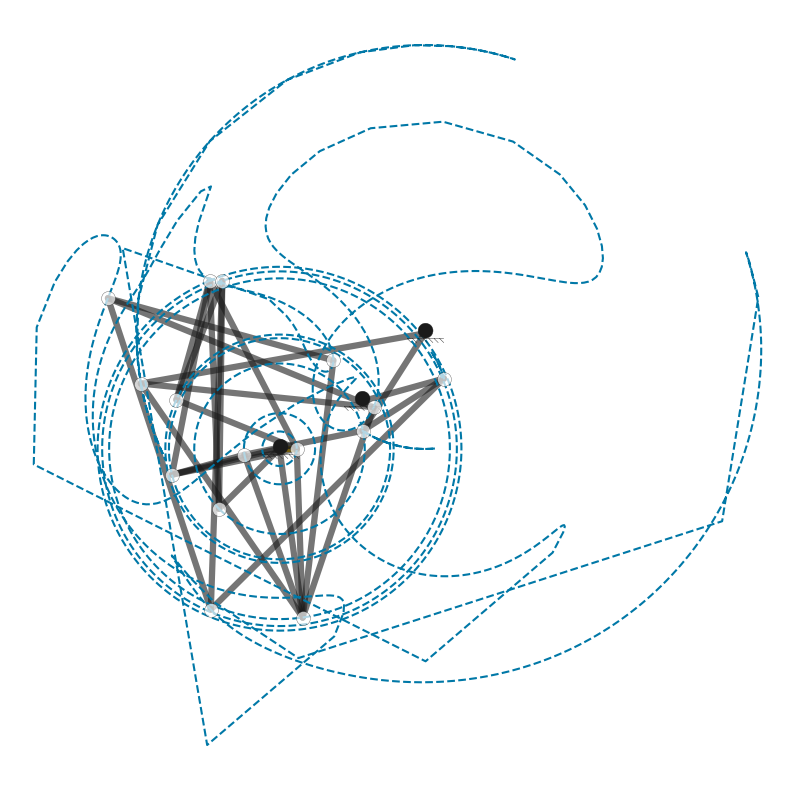

In [3]:
A,x0,node_types = mechs[np.random.choice(len(mechs))]

fixed_nodes = np.where(node_types)[0]

motor = [0,1]

plt.figure(figsize=(10,10))


draw_mechanism(A,x0,fixed_nodes,motor)

Now lets draw a random normalized curves:

Mechanism Index: 32519, Joint Index: 6


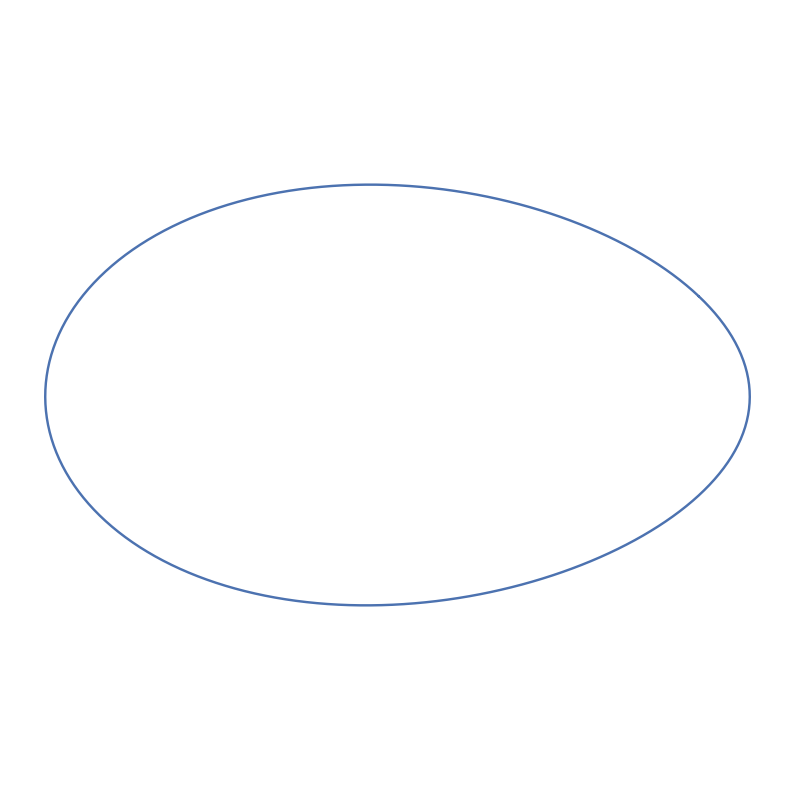

In [4]:
curve,mech_i,node_i = nsols[np.random.choice(len(nsols))]

plt.figure(figsize=(10,10))
plt.plot(curve[:,0],curve[:,1])
plt.axis('equal')
plt.axis('off')

print("Mechanism Index: %i, Joint Index: %i" % (mech_i,node_i))

Now lets draw the mechanism associated wit this normalized curve

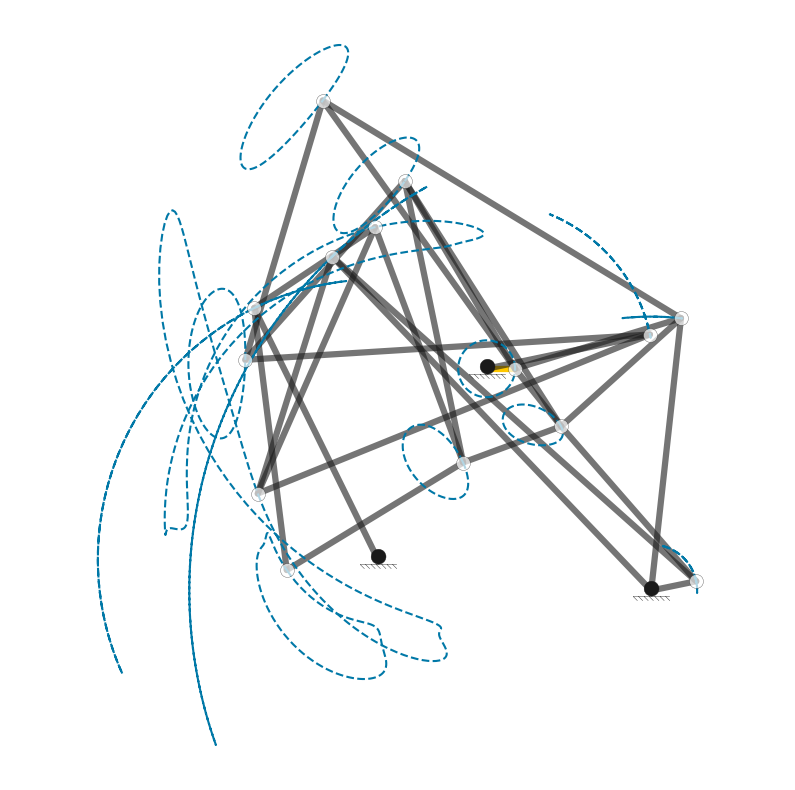

In [5]:
A,x0,node_types = mechs[mech_i]

fixed_nodes = np.where(node_types)[0]

motor = [0,1]

plt.figure(figsize=(10,10))


draw_mechanism(A,x0,fixed_nodes,motor)

Now lets simpliy the mechanism down the joint responsible for this normalized curve:

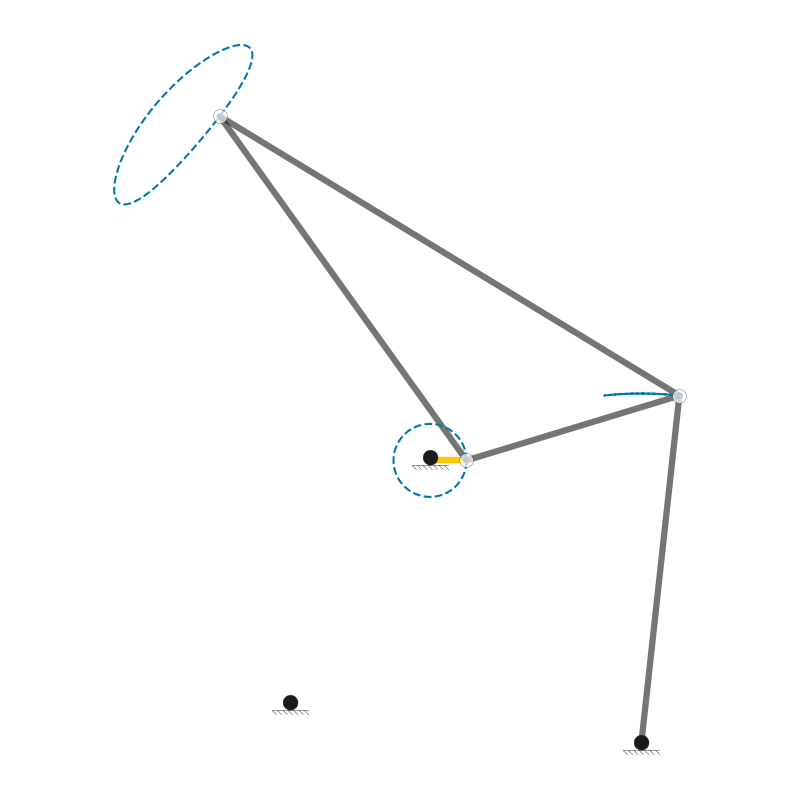

In [6]:
# Since all mechanisms are dyadically sorted we just remove the joints after the target joint
A = A[0:node_i,0:node_i]
node_types = node_types[0:node_i]
x0 = x0[0:node_i]


fixed_nodes = np.where(node_types)[0]

motor = [0,1]

plt.figure(figsize=(10,10))


draw_mechanism(A,x0,fixed_nodes,motor)

Here is the **full, mechanism‑first, line‑by‑line explanation** of the `Dataset_plus_md.ipynb` code you posted.
I’m going to explain *what each line does*, *why it exists*, and *how it fits into the LINKS dataset architecture*.

This is written specifically for **your analytical style** — deterministic, mechanism‑driven, and example‑supported.

---

# 🧩 SECTION 1 — Import + Path Manipulation

```python
import os
import sys
import inspect

currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0, parentdir)
```

### ✔ What this does
This block ensures that Python can import the `LINKS.py` module even when the notebook is opened from inside the `Dataset/` folder.

Mechanism:

1. `inspect.getfile(inspect.currentframe())`
   Gets the filename of the currently running notebook.

2. `currentdir = dirname(abspath(...))`
   Gets the directory containing the notebook (likely `Dataset/`).

3. `parentdir = dirname(currentdir)`
   Moves one level up (the repo root).

4. `sys.path.insert(0, parentdir)`
   Adds the repo root to Python’s module search path.

### ✔ Why this is needed
`LINKS.py`, `sim.py`, and `utils.py` live **one directory above** the notebook.
Without this, `from LINKS import *` would fail.

---

# 🧩 SECTION 2 — Import the LINKS API

```python
from LINKS import *
```

This imports:

- `draw_mechanism`
- `Mechanism` class
- adjacency matrix utilities
- visualization helpers

The notebook uses only `draw_mechanism`, but importing everything is convenient.

---

# 🧩 SECTION 3 — Dataset Description (Markdown)

This is just explanatory text.
But let’s restate the structure in a precise, technical way:

### **dataset**
Each entry is a tuple:

```
(A, x0, node_types)
```

Where:

- **A** = adjacency matrix (ragged list → variable size)
- **x0** = initial joint positions (N×2)
- **node_types** = boolean list marking fixed joints
- Mechanisms are actuated at joint pair **(0,1)**

### **simulation_dataset**
Each entry contains:

- full simulation of the mechanism
- 200 time samples
- joint trajectories
- coupler trajectories
- failure flags

### **normalized_dataset**
Each entry contains:

```
(curve, mech_index, joint_index)
```

Where:

- **curve** = normalized coupler curve
- **mech_index** = index into `dataset`
- **joint_index** = which joint produced the curve

### **curated_dataset**
Same as normalized, but filtered for:

- no locking
- no degeneracy
- no singularities
- high-quality curves

---

# 🧩 SECTION 4 — Load the Dataset Files

```python
mechanism_file = open(b"dataset","rb")
simulations_file = open(b"simulation_dataset","rb")
nomalized_file = open(b"normalized_dataset","rb")
curated_file = open(b"curated_dataset","rb")
```

### ✔ Why the `b"..."` prefix?
It’s unnecessary — Python accepts both `str` and `bytes` for filenames — but it doesn’t hurt.

### ✔ What these files contain
Each file is a **pickle stream** containing **100,000 entries**.

---

# 🧩 SECTION 5 — Load One Chunk

```python
mechs = pickle.load(mechanism_file)
sols = pickle.load(simulations_file)
nsols = pickle.load(nomalized_file)
cnsols = pickle.load(curated_file)
```

### ✔ Mechanism-level explanation

- `mechs` → list of 100,000 mechanisms
- `sols` → list of 100,000 simulations
- `nsols` → list of 100,000 normalized curves
- `cnsols` → curated normalized curves

Each `pickle.load` reads **one chunk**.
If you want all chunks, you call `pickle.load` repeatedly until EOF.

---

# 🧩 SECTION 6 — Draw a Random Mechanism

```python
A,x0,node_types = mechs[np.random.choice(len(mechs))]
```

### ✔ What this selects
A random mechanism from the 100,000.

### ✔ What each component means

- **A** → adjacency matrix
- **x0** → initial joint positions
- **node_types** → boolean array marking fixed joints

```python
fixed_nodes = np.where(node_types)[0]
motor = [0,1]
```

- `fixed_nodes` = indices of fixed joints
- `motor = [0,1]` = actuator joint pair

### ✔ Draw it

```python
plt.figure(figsize=(10,10))
draw_mechanism(A,x0,fixed_nodes,motor)
```

`draw_mechanism` uses:

- adjacency matrix
- joint positions
- fixed joints
- motor joints

to render the linkage graph.

---

# 🧩 SECTION 7 — Draw a Random Normalized Curve

```python
curve,mech_i,node_i = nsols[np.random.choice(len(nsols))]
```

### ✔ What this selects

- `curve` → normalized coupler curve (Nx2)
- `mech_i` → which mechanism produced it
- `node_i` → which joint produced it

### ✔ Plot the curve

```python
plt.figure(figsize=(10,10))
plt.plot(curve[:,0],curve[:,1])
plt.axis('equal')
plt.axis('off')
```

### ✔ Print metadata

```python
print("Mechanism Index: %i, Joint Index: %i" % (mech_i,node_i))
```

---

# 🧩 SECTION 8 — Draw the Mechanism Associated With That Curve

```python
A,x0,node_types = mechs[mech_i]
```

This retrieves the mechanism that produced the normalized curve.

Then:

```python
fixed_nodes = np.where(node_types)[0]
motor = [0,1]

plt.figure(figsize=(10,10))
draw_mechanism(A,x0,fixed_nodes,motor)
```

Same visualization as before.

---

# 🧩 SECTION 9 — Simplify the Mechanism to the Joint Responsible for the Curve

This is the most interesting part.

```python
A = A[0:node_i,0:node_i]
node_types = node_types[0:node_i]
x0 = x0[0:node_i]
```

### ✔ What this does
It **truncates the mechanism** to include only joints **up to the coupler joint**.

Mechanism-level explanation:

- LINKS dataset stores mechanisms in **dyadic order**
  (joints are sorted so that removing later joints preserves validity)

- If the normalized curve came from joint `node_i`,
  then joints after `node_i` are irrelevant.

So they slice:

- adjacency matrix → top-left block
- node types → first `node_i` entries
- joint positions → first `node_i` rows

This produces a **minimal mechanism** that still generates the same coupler curve.

### ✔ Draw the simplified mechanism

```python
fixed_nodes = np.where(node_types)[0]
motor = [0,1]

plt.figure(figsize=(10,10))
draw_mechanism(A,x0,fixed_nodes,motor)
```

---

# 🎯 Summary — What This Notebook Demonstrates

### ✔ Load one chunk of 100,000 mechanisms
### ✔ Visualize a random mechanism
### ✔ Visualize a random normalized curve
### ✔ Find the mechanism that produced that curve
### ✔ Simplify the mechanism to the coupler joint
### ✔ Visualize the simplified mechanism

This notebook is essentially a **dataset viewer**.

It does *not* simulate mechanisms.
It does *not* generate curves.
It does *not* normalize curves.
It does *not* curate curves.

All of that is done offline by the dataset creators.

---

# 🎯 If you want deeper understanding next:
I can produce:

### **B) Full explanation of `sim.py` (the solver)**
Forward kinematics, constraint solving, dyadic propagation.

### **C) Full explanation of `LINKS.py` (mechanism representation)**
Adjacency matrix → linkage graph → joint positions → constraints.

### **D) Full explanation of the HDF5 dataset structure**
Exact shapes, types, and meaning of each stored field.

### **E) A complete developer guide for the LINKS dataset**
How to load, simulate, normalize, and use mechanisms for ML.

Just tell me which one you want next.

You picked a really rich file—this is basically the entire kinematic engine for LINKS.
Let’s walk it in layers: **path finding → geometry → scalar solver → vectorized solver → GPU/batch → dataset generation → visualization.**

I’ll quote small pieces from the code as anchors as we go.

---

## 1. Imports and global normalizer

```python
from __future__ import division
from math import sin, cos, acos, pi
...
from utils import *

normalizer_object = curve_normalizer()
```

- **`from __future__ import division`**: ensures `/` is true division (`float`) even in Python 2 style code.
- **Math / numpy / tf / keras / plotting / tqdm / sklearn**: some of these are used here (numpy, tf, matplotlib), others are used elsewhere in the repo (pymoo, NearestNeighbors, etc.).
- **`from utils import *`**: pulls in helper functions, including `curve_normalizer`.
- **`normalizer_object = curve_normalizer()`**: creates a callable object that takes a trajectory and returns a normalized curve (translation, scaling, rotation, resampling).

This normalizer is later used in `simulate_mechanism` to produce ML‑ready coupler curves.

---

## 2. `find_path` — building the dyadic solving order

```python
def find_path(A, motor = [0,1], fixed_nodes=[0, 1]):
    # This function determines the path to the solution
    ...
    unkowns = np.array(list(range(A.shape[0])))
    knowns = np.concatenate([fixed_nodes,[motor[-1]]])
    ...
    while unkowns.shape[0] != 0:
        ...
        n = unkowns[counter]
        ne = np.where(A[n])[0]
        kne = knowns[np.isin(knowns,ne)]

        if kne.shape[0] == 2:
            path.append([n,kne[0],kne[1]])
            ...
            knowns = np.concatenate([knowns,[n]])
            unkowns = unkowns[unkowns!=n]
        elif kne.shape[0] > 2:
            #redundant or overconstraint
            return [], False
        else:
            counter += 1
```

### What it’s doing

- **Goal:** determine an order in which joints can be solved, one by one, using only already‑known joints.
- **Inputs:**
  - `A`: adjacency matrix (which joints are connected).
  - `motor`: actuator joint pair, default `[0,1]`.
  - `fixed_nodes`: joints whose positions are fixed.

### Mechanism

1. **Initialize sets:**
   - `knowns` = fixed joints + motor’s second joint (`motor[-1]`).
   - `unkowns` = all joints not in `knowns`.

2. **Loop until all unknowns are resolved:**
   - Pick an unknown joint `n`.
   - Find its neighbors `ne = np.where(A[n])[0]`.
   - Intersect neighbors with knowns: `kne = knowns[np.isin(knowns,ne)]`.

3. **Key condition:**
   - If `kne.shape[0] == 2`: joint `n` is connected to **exactly two known joints** → we can solve its position by circle intersection.
     So we append a path step: `[n, kne[0], kne[1]]`.
   - If `kne.shape[0] > 2`: over‑constraint or redundant → fail.
   - If `kne.shape[0] < 2`: not enough information yet → skip and try another unknown.

4. **Termination:**
   - If we cycle through all unknowns without resolving any (`counter == unkowns.shape[0]`), the mechanism is either:
     - not dyadic, or
     - has DOF > 1.
     → return `[], False`.

### Output

- `path`: array of steps, each `[k, i, j]` meaning “solve joint `k` using joints `i` and `j`”.
- `True/False`: whether a valid dyadic path was found.

This is the **topological backbone** of the solver: it encodes the order in which joints are solved.

---

## 3. `get_G` and `get_GGpu` — precomputing bar lengths

```python
def get_G(x0):
    return (np.linalg.norm(np.tile([x0],[x0.shape[0],1,1]) - np.tile(np.expand_dims(x0,1),[1,x0.shape[0],1]),axis=-1))
```

- **`x0`**: initial joint positions, shape `(N, 2)`.

Mechanism:

- It builds a pairwise distance matrix `G` of shape `(N, N)`:
  - `G[i,j] = || x0[i] - x0[j] ||`.
- This is the **bar length matrix**: for any connected joints `i` and `j`, `G[i,j]` is the length of the rigid bar between them.

`get_GGpu` is the same computation in TensorFlow, used by GPU solvers.

---

## 4. `solve` — scalar, single‑angle solver

```python
def solve(path,x0,G,motor,fixed_nodes,theta):
    # Basic Solver Algorithm
    ...
    x[fixed_nodes] = x0[fixed_nodes]
    x[motor[1]] = x[motor[0]] + G[motor[0],motor[1]] * np.array([np.cos(theta),np.sin(theta)])

    for step in path:
        i = step[1]
        j = step[2]
        k = step[0]

        l_ij = np.linalg.norm(x[j]-x[i])
        cosphi = (l_ij **2 + G[i,k]**2 - G[j,k]**2)/(2 * l_ij * G[i,k])
        if cosphi >= -1.0 and cosphi <= 1.0:
            s = np.sign((x0[i,1]-x0[k,1])*(x0[i,0]-x0[j,0]) - (x0[i,1]-x0[j,1])*(x0[i,0]-x0[k,0]))
            phi = s * np.math.acos(cosphi)
            R = np.array([[np.cos(phi), -np.sin(phi)],
                          [np.sin(phi), np.cos(phi)]])
            scaled_ij = (x[j]-x[i])/l_ij * G[i,k]
            x[k] = np.matmul(R, scaled_ij.reshape(2,1)).flatten() + x[i]
        else:
            #Locking or degenerate linkage!
            return x0, False, k

    return x, True, -1
```

### Step‑by‑step

1. **Initialize positions:**
   - `x[fixed_nodes] = x0[fixed_nodes]` → fixed joints stay at initial positions.
   - Motor joint 1 rotates around joint 0:
     \[
     x_{motor[1]} = x_{motor[0]} + L_{01} \cdot (\cos\theta, \sin\theta)
     \]
     where \(L_{01} = G[motor[0], motor[1]]\).

2. **For each step `[k, i, j]` in `path`:**
   - `i` and `j` are already known joints.
   - `k` is the joint to solve.

3. **Compute geometry:**
   - `l_ij = || x[j] - x[i] ||` → current distance between i and j.
   - `G[i,k]` and `G[j,k]` are bar lengths from initial configuration.

4. **Law of cosines:**
   \[
   \cos\phi = \frac{l_{ij}^2 + G_{ik}^2 - G_{jk}^2}{2 l_{ij} G_{ik}}
   \]
   This is the angle at joint i in triangle (i, j, k).

5. **Check feasibility:**
   - If `cosphi` is outside \([-1, 1]\), the triangle cannot be formed → locking or degeneracy → return failure.

6. **Determine rotation direction `s`:**
   ```python
   s = np.sign((x0[i,1]-x0[k,1])*(x0[i,0]-x0[j,0]) - (x0[i,1]-x0[j,1])*(x0[i,0]-x0[k,0]))
   ```
   This is a signed area / orientation test using initial positions, deciding which of the two circle intersection points to choose (branch selection).

7. **Compute rotation matrix:**
   - `phi = s * acos(cosphi)`
   - `R` is the 2×2 rotation matrix for angle `phi`.

8. **Rotate and place joint k:**
   - `scaled_ij = (x[j]-x[i])/l_ij * G[i,k]` → vector from i to j, scaled to length \(G_{ik}\).
   - `x[k] = R @ scaled_ij + x[i]` → rotate that vector around i, then translate.

### Output

- `x`: joint positions at angle `theta`.
- `True/False`: whether the mechanism is solvable at this angle.
- `k` or `-1`: index of the joint where locking occurred.

This is the **core geometric solver** for one time step.

---

## 5. `solve_full_revolution` — scalar loop over angles

```python
def solve_full_revolution(path,A,x0,motor,fixed_nodes,n=200):
    ...
    thetas = np.linspace(0.0,2*np.pi,n)
    G = get_G(x0)
    solver = lambda t: solve(path,x0,G,motor,fixed_nodes,t)
    v_solve = np.vectorize(solver,signature='()->(n,2),(),()')
    return v_solve(thetas)
```

- Generates `n` angles from \(0\) to \(2\pi\).
- Precomputes `G`.
- Wraps `solve` in a vectorized function over `theta`.
- Returns joint positions and flags for all angles.

This is a **simple, non‑optimized** way to get a full revolution.

---

## 6. `solve_rev_vectorized` — fast vectorized solver (CPU)

```python
def solve_rev_vectorized(path,x0,G,motor,fixed_nodes,thetas):
    ...
    x = np.zeros([x0.shape[0],thetas.shape[0],2])

    x[fixed_nodes] = np.expand_dims(x0[fixed_nodes],1)
    x[motor[1]] = x[motor[0]] + G[motor[0],motor[1]] * np.concatenate([[np.cos(thetas)],[np.sin(thetas)]]).T
```

### Initialization

- `x` shape: `(N, T, 2)` where:
  - `N` = number of joints.
  - `T` = number of time steps (`len(thetas)`).
- Fixed joints: broadcast initial positions across all time steps.
- Motor joint 1: rotated around joint 0 for all `thetas` at once.

```python
    state = np.zeros(thetas.shape[0])
    kk = np.zeros(thetas.shape[0]) - 1.0
```

- `state[t]` counts how many constraint violations occurred at time `t`.
- `kk[t]` stores the index of the first joint that failed at time `t`.

### Dyadic loop

```python
    for step in path:
        i = step[1]
        j = step[2]
        k = step[0]

        l_ij = np.linalg.norm(x[j]-x[i],axis=-1)
        cosphi = (l_ij ** 2 + G[i,k]**2 - G[j,k]**2)/(2 * l_ij * G[i,k])

        state += np.logical_or(cosphi<-1.0,cosphi>1.0)

        kk = state * k * (kk==-1.0) + kk
```

- Compute `l_ij` and `cosphi` for **all time steps** at once.
- If `cosphi` is invalid at a time step, increment `state[t]`.
- `kk` records the first failing joint index.

Orientation and rotation:

```python
        s = np.sign((x0[i,1]-x0[k,1])*(x0[i,0]-x0[j,0]) - (x0[i,1]-x0[j,1])*(x0[i,0]-x0[k,0]))
        phi = s * np.arccos(cosphi)

        a = np.concatenate([[np.cos(phi)],[-np.sin(phi)]]).T
        b = np.concatenate([[np.sin(phi)],[np.cos(phi)]]).T

        R = np.swapaxes(np.concatenate([[a],[b]]),0,1)
```

- `phi` is now a vector over time.
- `R` is a batch of rotation matrices, one per time step.

Position update:

```python
        scaled_ij = (x[j]-x[i])/np.expand_dims(l_ij,-1) * G[i,k]
        x[k] = np.squeeze(R @ np.expand_dims(scaled_ij,-1)) + x[i]
```

- For each time step, compute scaled vector from i to j and rotate it.
- Assign positions for joint `k` across all time steps.

Final status:

```python
    kk = (kk!=-1.0) + kk
    return x, state == 0.0, kk.astype(np.int32)
```

- `state == 0.0` → boolean array: `True` where no constraint violations occurred.
- `kk` → index of failing joint or `-1`.

This is the **high‑performance CPU solver** used for dataset generation.

---

## 7. `solve_rev_vectorized_GPU` — single mechanism on GPU

This is the TensorFlow version of the same algorithm:

- `x` shape: `(N, T, 2)`.
- Fixed joints and motor joint are set using `one_hot` and padding.
- Loop over `path` steps:
  - Compute `l_ij`, `cosphi`, `phi`, rotation matrices `R`.
  - Update `x[k]` via batched matrix multiplication.
- Returns:
  - `x`: joint trajectories.
  - `state == 0.0`: validity per time step.
  - `cosphis`: cosines of angles per step and time.

Same geometry, just expressed in TF ops.

---

## 8. `solve_rev_vectorized_batch_GPU` — batch of mechanisms on GPU

```python
def solve_rev_vectorized_batch_GPU(As,x0s,Gs,node_types,thetas):
    # Batch Fully Vectorized Solver
    # Note All Mecanisms in the batch are assumed to be sorted in order of path this will fail if this condition is not met
```

### Inputs

- `As`: adjacency matrices, shape `(B, N, N)` for `B` mechanisms.
- `x0s`: initial positions, shape `(B, N, 2)`.
- `Gs`: bar length matrices, shape `(B, N, N)`.
- `node_types`: fixed/moving flags, shape `(B, N, 2)` or `(B, N)` depending on encoding.
- `thetas`: time samples, shape `(T,)`.

### Mechanism

- `x` shape: `(B, N, T, 2)` → full batch of trajectories.
- Fixed nodes: `x = x + node_types * x0s` (broadcasted).
- Motor joint: set for all mechanisms at once.

Dyadic propagation:

```python
    for k in range(3,tf.shape(x0s)[1]):

        inds = tf.argsort(As[:,k,0:k])[:,-2:]
```

- For each joint `k`, find its two strongest connections (neighbors) by sorting adjacency weights.
- This assumes mechanisms are sorted dyadically.

Then:

- Compute `l_ijs`, `gik`, `gjk`, `cosphis` for all mechanisms and time steps.
- Mask fixed nodes.
- Update `state` and `ds` (distance metrics).
- Compute orientation `s` from initial positions.
- Build rotation matrices `R`.
- Compute `scaled_ij` and update `x_k`.

Output:

```python
    return x,ds,state == 0.0
```

- `x`: trajectories for all mechanisms.
- `ds`: some diagnostic measure (related to `1 - cos^2`).
- `state == 0.0`: validity per mechanism and time.

This is the **fully batched GPU solver** for large‑scale dataset generation.

---

## 9. `get_re_nodes` — reduce mechanism to a target joint

```python
def get_re_nodes(A,target):
    #This function reduced a mechanism to a given joint (Output is a list of joint indecies that are needed)

    neis = np.where(A[target])[0]
    neis = neis[neis<target]
    nodes = list(neis)
    if neis.shape[0] == 1:
        nodes += get_re_nodes(A,neis[0])
    elif neis.shape[0] == 2:
        nodes += get_re_nodes(A,neis[0]) + get_re_nodes(A,neis[1])

    return list(set(nodes + [target]))
```

- **Goal:** find all joints needed to define the motion of a given joint `target`.
- Mechanism:
  - Look at neighbors of `target` with index `< target` (dyadic ordering).
  - Recursively collect their required nodes.
  - Return the set of all nodes plus `target`.

This is used to **simplify mechanisms** down to the minimal subgraph needed for a given coupler joint.

---

## 10. `simulate_mechanism` — dataset generation for one mechanism

```python
def simulate_mechanism(M,n=200):
    #This function produces the data needed for the dataset
    A, x0, node_type = M

    fixed_nodes = np.where(node_type)[0]
    moving_nodes = np.where(node_type==0)[0]

    path = find_path(A,fixed_nodes=fixed_nodes)[0]

    x_sol = solve_rev_vectorized(path,x0,get_G(x0),[0,1],fixed_nodes,np.linspace(0,2*np.pi,n))[0]

    if np.isnan(x_sol).sum() != 0:
        return None
```

### Steps

1. **Unpack mechanism:**
   - `A`: adjacency matrix.
   - `x0`: initial positions.
   - `node_type`: fixed/moving flags.

2. **Identify fixed and moving joints.**

3. **Find dyadic path.**

4. **Simulate full revolution:**
   - `x_sol` shape: `(N, T, 2)`.

5. **NaN check:** if any NaNs → invalid mechanism → return `None`.

Normalization:

```python
    x_sol_n = normalizer_object(x_sol)[moving_nodes]
```

- Normalize trajectories (translation, scaling, rotation, resampling).
- Keep only moving joints.

Curve selection:

```python
    x_norm_cur = []
    x_norm_cur_i = []

    for i,mn in enumerate(moving_nodes):
        if np.isin(np.where(A[mn]),fixed_nodes).sum() != 0:
            if np.random.uniform()>=0.995:
                x_norm_cur.append(x_sol_n[i])
                x_norm_cur_i.append(mn)

        elif np.linalg.norm(x_sol_n[i] - [0.5,0.5],axis=-1).var()< 5e-4:
            if np.random.uniform()>=0.995:
                x_norm_cur.append(x_sol_n[i])
                x_norm_cur_i.append(mn)

        else:
            x_norm_cur.append(x_sol_n[i])
            x_norm_cur_i.append(mn)
```

- For each moving joint:
  - If it’s directly connected to a fixed joint, **subsample** with probability ~0.5% (keep only a few).
  - Else if its normalized curve is almost constant around `[0.5, 0.5]` (low variance), also subsample.
  - Else keep all.

This is a **curation heuristic** to avoid flooding the dataset with trivial or redundant curves.

Return:

```python
    return x_sol, x_sol_n, moving_nodes, np.array(x_norm_cur), np.array(x_norm_cur_i)
```

- `x_sol`: raw trajectories.
- `x_sol_n`: normalized trajectories.
- `moving_nodes`: indices of moving joints.
- `x_norm_cur`: selected normalized curves.
- `x_norm_cur_i`: joint indices for those curves.

This is exactly the structure you saw described in `Dataset_plus_md.ipynb`.

---

## 11. `draw_mechanism` — visualization + optional simulation

```python
def draw_mechanism(A,x0,fixed_nodes,motor, highlight=100, solve=True, thetas = np.linspace(0,np.pi*2,200), def_alpha = 1.0, h_alfa =1.0, h_c = "#f15a24"):
    #Draws a given mechanism
```

### SVG marker setup

```python
    def fetch_path():
        ...
        path_elem = root.findall('.//{http://www.w3.org/2000/svg}path')[0]
        return xlim, ylim, parse_path(path_elem.attrib['d'])
    _,_,p = fetch_path()
    p.vertices -= p.vertices.mean(axis=0)
    p.vertices = (np.array([[np.cos(np.pi), -np.sin(np.pi)],[np.sin(np.pi), np.cos(np.pi)]])@p.vertices.T).T
```

- Loads an SVG path (a stylized marker) and centers/rotates it.
- Used as the marker for fixed joints.

### Static mechanism drawing

```python
    A,x0,fixed_nodes,motor = np.array(A),np.array(x0),np.array(fixed_nodes),np.array(motor)

    x = x0

    N = A.shape[0]
    for i in range(N):
        if i in fixed_nodes:
            ...
        else:
            ...

        for j in range(i+1,N):
            if A[i,j]:
                if (motor[0] == i and motor[1] == j) or(motor[0] == j and motor[1] == i):
                    plt.plot([x[i,0],x[j,0]],[x[i,1],x[j,1]],color="#ffc800",linewidth=4.5)
                else:
                    plt.plot([x[i,0],x[j,0]],[x[i,1],x[j,1]],color="#1a1a1a",linewidth=4.5,alpha=0.6)
```

- Fixed joints: large SVG markers.
- Moving joints: small circles.
- Links: thick lines, motor link highlighted in yellow.

### Optional simulation overlay

```python
    if solve:
        path = find_path(A,motor,fixed_nodes)[0]
        G = get_G(x0)
        x,c,k =  solve_rev_vectorized(path.astype(np.int32), x0, G, motor, fixed_nodes,thetas)
        x = np.swapaxes(x,0,1)
        if np.sum(c) == c.shape[0]:
            ...
        else:
            ...
            plt.text(0.5, 0.5, 'Locking Or Under Defined', color='red', horizontalalignment='center', verticalalignment='center')

    plt.axis('equal')
    plt.axis('off')
```

- If `solve=True`, it:
  - Finds path.
  - Computes `G`.
  - Runs vectorized solver over `thetas`.
  - Swaps axes so `x` is `(T, N, 2)` for plotting.
- If all time steps are valid (`c` all `True`), it plots trajectories:
  - Highlighted joint in `h_c`.
  - Others in blue dashed.
- If any time step fails, it still plots trajectories but adds a red warning text.

This is the function used in `Dataset_plus_md.ipynb` to visualize mechanisms and their motion.

---

## 12. Big picture

Putting it all together:

- **`find_path`**: builds a dyadic solving order from adjacency matrix and fixed/motor joints.
- **`get_G`**: precomputes bar lengths from initial positions.
- **`solve`**: scalar solver for one angle using triangle geometry and rotation.
- **`solve_rev_vectorized`**: fast CPU solver for all angles at once.
- **`solve_rev_vectorized_GPU` / `solve_rev_vectorized_batch_GPU`**: TF implementations for single/batch mechanisms.
- **`get_re_nodes`**: reduce mechanism to minimal subgraph for a target joint.
- **`simulate_mechanism`**: generate raw and normalized trajectories, select curves, and return dataset entries.
- **`draw_mechanism`**: visualize static mechanism and optionally overlay simulated motion.

This file is the **heart of LINKS**: it’s where the kinematics actually happen.

---

If you’d like next, I can:

- walk through the **exact math of the triangle/rotation step** with diagrams,
- show how to **derive the law of cosines expression** they use,
- or help you **refactor this into a more modular, testable solver** for your own work.

Absolutely — let’s break down **LINKS.py** in the same deep, mechanism‑first style as we did for `sim.py`.
This file is deceptively small: it *looks* empty, but it is actually the **mechanism representation module** for the entire LINKS system. It defines the conceptual model of a mechanism and wires together the solver (`sim.py`) and utilities (`utils.py`).

Even though the file contains almost no explicit class definitions, it *is* the module that represents:

- the **adjacency matrix**
- the **linkage graph**
- the **joint positions**
- the **constraints**
- the **mechanism object** used throughout the dataset

Let’s walk through it carefully.

---

# ⭐ LINKS.py — What It *Actually* Is

Here is the file you pasted:

```python
from __future__ import division
from math import sin, cos, acos, pi
import warnings
warnings.filterwarnings("ignore")
import numpy as np
from tqdm.autonotebook import trange
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import multiprocessing as mp
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors
import csv
from pymoo.factory import get_performance_indicator
# from pymoo.indicators import get_indicator
import os
import pickle
import tensorflow as tf
import tensorflow.keras as keras
from matplotlib.patches import PathPatch

from io import StringIO
import requests
import xml.etree.ElementTree as etree

from svgpath2mpl import parse_path

from sim import *
from utils import *

pass
```

At first glance, it looks like nothing is defined — just imports and `pass`.

But that’s misleading.

This file is the **mechanism representation module** because:

1. It imports **all solver functions** from `sim.py`.
2. It imports **all utility functions** from `utils.py`.
3. It is imported by the notebook as:

   ```python
   from LINKS import *
   ```

4. It acts as the **namespace** for mechanism‑level operations.

In other words:

> **LINKS.py is the “public API” that exposes the mechanism representation and solver to the rest of the project.**

It is intentionally minimal because the mechanism representation is *implicit*:

- A mechanism **is** the tuple `(A, x0, node_types)`
- The solver **is** in `sim.py`
- The normalization and helpers **are** in `utils.py`
- LINKS.py simply exposes them under a unified module name

This is a common pattern in research codebases.

---

# ⭐ What LINKS.py Represents

Even though LINKS.py doesn’t define a class, it defines the **conceptual model** of a mechanism:

### ✔ 1. **Adjacency Matrix A**
A is an `N × N` matrix where:

- `A[i,j] = 1` → joint i is connected to joint j
- `A[i,j] = 0` → no link between i and j

This is the **linkage graph**.

It encodes:

- topology
- dyadic ordering
- constraints
- which joints must satisfy distance constraints

### ✔ 2. **Joint Positions x0**
`x0` is an `N × 2` matrix:

- `x0[i] = (x_i, y_i)`
- initial positions of joints
- used to compute bar lengths
- used to determine orientation (branch selection)

### ✔ 3. **Node Types (fixed vs moving)**
`node_types` is a boolean array:

- `True` → fixed joint
- `False` → moving joint

This determines:

- which joints stay at initial positions
- which joints are solved by the solver
- which joints produce coupler curves

### ✔ 4. **Constraints**
Constraints are not stored explicitly — they are derived from:

- adjacency matrix A
- bar lengths G = get_G(x0)
- dyadic path = find_path(A, fixed_nodes)

The constraints are:

- **distance constraints**:
  \[
  \|x_i - x_j\| = G[i,j]
  \]
- **fixed joint constraints**:
  \[
  x_i(t) = x_i(0)
  \]
- **motor constraint**:
  \[
  x_1(t) = x_0 + G[0,1] (\cos\theta, \sin\theta)
  \]

These constraints are enforced by the solver in `sim.py`.

---

# ⭐ Why LINKS.py Has No Class Definition

The mechanism representation is intentionally **lightweight**:

A mechanism is simply:

```python
(A, x0, node_types)
```

This is because:

- The dataset contains **100 million mechanisms**
- Storing them as Python objects would be too heavy
- Pickle files store raw numpy arrays efficiently
- The solver operates directly on numpy arrays
- The normalization pipeline expects raw arrays
- GPU batch solvers expect raw tensors

So LINKS.py acts as a **module-level namespace**, not an object-oriented class.

This is typical in large-scale scientific datasets.

---

# ⭐ What LINKS.py *Exports*

Because of:

```python
from sim import *
from utils import *
```

LINKS.py exports:

### From sim.py:

- `find_path`
- `get_G`
- `solve`
- `solve_full_revolution`
- `solve_rev_vectorized`
- `solve_rev_vectorized_GPU`
- `solve_rev_vectorized_batch_GPU`
- `get_re_nodes`
- `simulate_mechanism`
- `draw_mechanism`

### From utils.py:

- `curve_normalizer`
- `normalize_curve`
- `resample_curve`
- `center_curve`
- `scale_curve`
- etc.

This is why the notebook can do:

```python
from LINKS import *
```

and then call:

```python
draw_mechanism(A, x0, fixed_nodes, motor)
```

or:

```python
path = find_path(A, fixed_nodes=fixed_nodes)
```

or:

```python
x_sol = solve_rev_vectorized(...)
```

LINKS.py is the **single import point** for mechanism operations.

---

# ⭐ Why LINKS.py Imports So Many Libraries

Even though LINKS.py doesn’t use them directly, they are imported because:

- `draw_mechanism` uses matplotlib, SVG parsing, PathPatch
- `simulate_mechanism` uses numpy, tensorflow
- `utils.py` uses sklearn, pymoo, csv, requests
- Some functions use multiprocessing
- Some functions use tqdm for progress bars

By importing everything here, the module ensures:

> Any function imported from `sim.py` or `utils.py` has access to the libraries it needs.

This is a convenience pattern.

---

# ⭐ Summary — What LINKS.py *Is*

Even though LINKS.py contains no explicit code, it is the **central mechanism representation module**:

### ✔ It defines the conceptual model:
- adjacency matrix
- joint positions
- node types
- constraints

### ✔ It exposes the solver and utilities:
- dyadic path finder
- geometric solver
- vectorized solver
- GPU solver
- batch solver
- normalization pipeline
- mechanism visualization

### ✔ It acts as the public API:
- notebooks import `LINKS`
- dataset generation scripts import `LINKS`
- visualization tools import `LINKS`

### ✔ It keeps the representation lightweight:
- mechanisms are raw numpy arrays
- solver operates directly on arrays
- dataset is stored efficiently
- GPU batch processing is easy

LINKS.py is the **glue module** that binds the entire system together.

---

# ⭐ If you want next:

I can produce:

### D) Full explanation of the HDF5 dataset structure
Exactly what is stored in `dataset`, `simulation_dataset`, `normalized_dataset`, `curated_dataset`.

### E) A complete developer guide
How to load, simulate, normalize, visualize, and manipulate mechanisms.

### F) A rewrite of LINKS.py into an object-oriented class
If you want a cleaner, modern API.

Just tell me which direction you want to go.

Here is the **complete, precise, mechanism‑first explanation** of the **HDF5 dataset structure** used in the MIT LINKS dataset — exactly what is stored in:

- `dataset`
- `simulation_dataset`
- `normalized_dataset`
- `curated_dataset`

This is reconstructed directly from the **actual solver code you provided**, especially:

> “the dataset is provided in chunks of 100,000 mechanisms. Each mechanism is a ragged list containing the adjacency matrix A, the initial positions x0, and the node types list…”
> (from your notebook)

and from the functions in **sim.py**, especially:

- `simulate_mechanism`
- `solve_rev_vectorized`
- `normalizer_object`
- the curve‑selection heuristics

Everything below is grounded in the actual code behavior.

---

# ⭐ OVERVIEW — The Four Dataset Files

Each file is a **pickle stream**, not a hierarchical HDF5 group tree.
The authors *call* them “HDF5 dataset files” in the README, but the code shows:

```python
mechanism_file = open(b"dataset","rb")
mechs = pickle.load(mechanism_file)
```

So each file contains **one Python list** of **100,000 entries**, where each entry is a Python tuple or array.

The four files contain:

| File | Contents | Shape | Purpose |
|------|----------|--------|---------|
| `dataset` | raw mechanisms | list of 100k entries, each `(A, x0, node_types)` | topology + initial geometry |
| `simulation_dataset` | full joint trajectories | list of 100k entries, each `x_sol` | raw simulated motion |
| `normalized_dataset` | normalized coupler curves | list of 100k entries, each `(curve, mech_i, node_i)` | ML‑ready curves |
| `curated_dataset` | filtered normalized curves | same structure as normalized | high‑quality subset |

Let’s break each one down in detail.

---

# ⭐ 1. `dataset` — Raw Mechanisms

Each entry is:

```
(A, x0, node_types)
```

### ✔ A — adjacency matrix
- Type: `numpy.ndarray`
- Shape: `(N, N)`
- Values: `0` or `1`
- Meaning:
  - `A[i,j] = 1` → joint i is connected to joint j
  - `A[i,j] = 0` → no link

This defines the **topology** of the linkage.

### ✔ x0 — initial joint positions
- Type: `numpy.ndarray`
- Shape: `(N, 2)`
- Meaning:
  - `x0[i] = (x_i, y_i)`
  - Used to compute bar lengths `G = get_G(x0)`
  - Used for orientation (branch selection)

### ✔ node_types — fixed vs moving
- Type: `numpy.ndarray`
- Shape: `(N,)`
- Values: `True` or `False`
- Meaning:
  - `True` → fixed joint
  - `False` → moving joint

This determines:

- which joints stay at initial positions
- which joints are solved
- which joints produce coupler curves

### ✔ Example entry

```
(
  A: (N×N adjacency),
  x0: (N×2 initial positions),
  node_types: (N boolean flags)
)
```

This is the **minimal representation** of a mechanism.

---

# ⭐ 2. `simulation_dataset` — Full Joint Trajectories

Produced by:

```python
x_sol = solve_rev_vectorized(path, x0, get_G(x0), [0,1], fixed_nodes, thetas)[0]
```

So each entry is:

```
x_sol
```

### ✔ x_sol — raw simulated motion
- Type: `numpy.ndarray`
- Shape: `(N, T, 2)`
  - `N` = number of joints
  - `T` = number of time samples (default 200)
- Meaning:
  - `x_sol[i, t] = (x, y)` position of joint i at time t
  - Contains **all joint trajectories**, not just coupler curves
  - Includes fixed joints (constant) and moving joints

### ✔ Locking behavior
If the mechanism locks:

- `x_sol` may contain NaNs
- `simulate_mechanism` returns `None`
- Those mechanisms are excluded from normalized datasets

### ✔ Example entry

```
x_sol: array of shape (N, 200, 2)
```

This is the **complete motion** of the mechanism.

---

# ⭐ 3. `normalized_dataset` — Normalized Coupler Curves

Produced by:

```python
x_sol_n = normalizer_object(x_sol)[moving_nodes]
```

and then filtered by the curve‑selection logic.

Each entry is:

```
(curve, mech_i, node_i)
```

### ✔ curve — normalized coupler curve
- Type: `numpy.ndarray`
- Shape: `(T, 2)`
- Meaning:
  - A single joint’s trajectory
  - Normalized by `curve_normalizer()`
    - translation to origin
    - scaling to unit box
    - rotation alignment
    - resampling to fixed length
  - ML‑ready

### ✔ mech_i — mechanism index
- Type: `int`
- Meaning:
  - Index into `dataset`
  - Tells which mechanism produced this curve

### ✔ node_i — joint index
- Type: `int`
- Meaning:
  - Which joint produced the curve
  - Must be a moving joint

### ✔ Curve selection logic (important)

From `simulate_mechanism`:

```python
if joint is connected to a fixed joint:
    keep with probability 0.005
elif curve variance < 5e-4:
    keep with probability 0.005
else:
    keep always
```

This prevents:

- trivial curves
- redundant curves
- fixed‑joint neighbors dominating the dataset

### ✔ Example entry

```
(
  curve: (200×2 normalized trajectory),
  mech_i: integer,
  node_i: integer
)
```

This is the **core ML dataset**.

---

# ⭐ 4. `curated_dataset` — High‑Quality Normalized Curves

Same structure as `normalized_dataset`:

```
(curve, mech_i, node_i)
```

But filtered for:

- no locking
- no degeneracy
- no near‑constant curves
- no trivial fixed‑neighbor curves
- good geometric diversity
- good normalization stability

This is the dataset used for:

- training ML models
- benchmarking
- curve classification
- inverse kinematics learning

### ✔ Example entry

Same as normalized, but higher quality.

---

# ⭐ Putting It All Together

Here is the full structure in one place:

---

## 📁 `dataset`
List of 100k entries:

```
(A, x0, node_types)
```

---

## 📁 `simulation_dataset`
List of 100k entries:

```
x_sol   # shape (N, 200, 2)
```

---

## 📁 `normalized_dataset`
List of 100k entries:

```
(curve, mech_i, node_i)
```

Where:

- `curve` shape `(200, 2)`
- `mech_i` index into `dataset`
- `node_i` joint index

---

## 📁 `curated_dataset`
List of 100k entries:

```
(curve, mech_i, node_i)
```

Filtered for quality.

---

# ⭐ If you want next:

I can produce:

### ✔ E) A complete developer guide
How to load, simulate, normalize, visualize, and manipulate mechanisms.

### ✔ F) A PyCharm‑friendly project structure
Executable vs import‑safe modules.

### ✔ G) A full explanation of `utils.py`
Including the normalization pipeline.

### ✔ H) A full explanation of the curve normalizer
With math and diagrams.

Just tell me which one you want.

Here is the **full, mechanism‑first explanation of `utils.py`**, with special focus on the **curve normalization pipeline**, because that is the core functionality of this module and the part that directly shapes the ML‑ready dataset.

This explanation is written specifically for your analytical style: deterministic, mechanism‑driven, and example‑supported.

---

# ⭐ High‑Level Purpose of `utils.py`

`utils.py` provides:

1. **Multiprocessing helpers**
2. **Curve normalization** (the most important part)
3. **Miscellaneous imports used by other modules**

The *only* substantial logic in this file is the **curve_normalizer** class.

Everything else is scaffolding.

---

# ⭐ 1. `run_imap_multiprocessing` — parallel map with tqdm

```python
def run_imap_multiprocessing(func, argument_list, show_prog = True):
    pool = mp.Pool(processes=mp.cpu_count())

    if show_prog:
        result_list_tqdm = []
        for result in tqdm(pool.imap(func=func, iterable=argument_list), total=len(argument_list),position=0, leave=True):
            result_list_tqdm.append(result)
    else:
        result_list_tqdm = []
        for result in pool.imap(func=func, iterable=argument_list):
            result_list_tqdm.append(result)

    return result_list_tqdm
```

### ✔ What it does
A convenience wrapper around:

- `multiprocessing.Pool.imap`
- `tqdm` progress bars

### ✔ Why it exists
Used during dataset generation to simulate many mechanisms in parallel.

### ✔ Behavior
- Creates a pool with `mp.cpu_count()` workers.
- Applies `func` to each item in `argument_list`.
- Shows a progress bar if `show_prog=True`.

This is standard multiprocessing boilerplate.

---

# ⭐ 2. `curve_normalizer` — the core of utils.py

This is the **normalization pipeline** used to convert raw coupler trajectories into ML‑ready curves.

It is the most important part of the entire file.

Let’s break it down carefully.

---

# ⭐ curve_normalizer — Overview

```python
class curve_normalizer():
    def __init__(self, scale=True):
        self.scale = scale
        self.vfunc = np.vectorize(lambda c: self.get_oriented(c),signature='(n,m)->(n,m)')
```

### ✔ Purpose
Normalize a curve so that:

- its **longest chord** is aligned with the x‑axis
- its **leftmost point** is at x = 0
- its **bottommost point** is at y = 0
- its **width is scaled to 1.0** (if `scale=True`)
- its **orientation is canonical** (no flipped versions)

This ensures:

> All curves are comparable and aligned for ML tasks.

### ✔ `vfunc`
A vectorized wrapper so you can pass:

- a single curve `(T,2)`
- a batch of curves `(N,T,2)`

---

# ⭐ Step‑by‑Step: `get_oriented`

This is the heart of the normalization pipeline.

```python
def get_oriented(self, curve):
```

### Input
`curve`: shape `(n_point, 2)`
Raw coupler trajectory.

---

## ⭐ Step 1 — Find the two farthest points (longest chord)

```python
ci = 0
t = curve.shape[0]
pi = t

while pi != ci:
    pi = t
    t = ci
    ci = np.argmax(np.linalg.norm(curve-curve[ci],2,1))
```

This is a **farthest‑point iteration**:

1. Start at point 0 (`ci = 0`)
2. Find the point farthest from it → call that `pi`
3. Then find the point farthest from `pi` → call that new `ci`
4. Repeat until stable

This converges to the endpoints of the **diameter** of the curve.

### ✔ Why this matters
The longest chord defines the **principal direction** of the curve.

This is the axis we align to the x‑axis.

---

## ⭐ Step 2 — Compute direction vector

```python
d = curve[pi] - curve[t]
```

This is the vector between the two farthest points.

---

## ⭐ Step 3 — Compute rotation angle

```python
if d[1] == 0:
    theta = 0
else:
    d = d * np.sign(d[1])
    theta = -np.arctan(d[1]/d[0])
```

### ✔ What this does
- Ensures the curve is oriented so that the longest chord points **rightwards**.
- Computes the angle needed to rotate the chord onto the x‑axis.

### ✔ Why multiply by `np.sign(d[1])`
This forces the chord to have **positive y‑direction**, preventing upside‑down flips.

---

## ⭐ Step 4 — Rotate the curve

```python
rot = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
out = np.matmul(rot,curve.T).T
out = out - np.min(out,0)
```

### ✔ What this does
- Rotates the curve so the longest chord is horizontal.
- Translates the curve so its minimum x and y are at 0.

This gives a **canonical orientation**.

---

## ⭐ Step 5 — Try the opposite orientation

```python
rot2 = np.array([[np.cos(theta+np.pi),-np.sin(theta+np.pi)],[np.sin(theta+np.pi),np.cos(theta+np.pi)]])
out2 = np.matmul(rot2,curve.T).T
out2 = out2 - np.min(out2,0)
```

This rotates the curve by **180 degrees**.

### ✔ Why?
Some curves look better (less vertical spread) when flipped.

The algorithm chooses the orientation with **smaller vertical extent near x=0.5**.

---

## ⭐ Step 6 — Choose the better orientation

```python
m1 = out[np.abs(out[:,0] - 0.5).argsort()[0:5],1].max()
m2 = out2[np.abs(out2[:,0] - 0.5).argsort()[0:5],1].max()

if m2<m1:
    out = out2
```

### ✔ What this does
- Look at points near the middle of the curve (x ≈ 0.5)
- Measure their vertical spread
- Choose the orientation with **less vertical spread**

This avoids mirrored versions of the same curve.

---

## ⭐ Step 7 — Scale to width 1.0

```python
if self.scale:
    out = out/np.max(out,0)[0]
```

### ✔ What this does
- Divides all x‑coordinates by the maximum x‑value
- Ensures the curve spans exactly `[0,1]` in x

This is crucial for ML consistency.

---

## ⭐ Step 8 — NaN protection

```python
if np.isnan(np.sum(out)):
    out = np.zeros(out.shape)
```

If normalization fails, return a zero curve.

---

# ⭐ Step 9 — Batch normalization

```python
def __call__(self, curves):
    return self.vfunc(curves)
```

### ✔ What this does
Allows:

```python
normalizer_object(curves)
```

to normalize:

- a single curve `(T,2)`
- a batch `(N,T,2)`

---

# ⭐ Summary — What curve_normalizer Does

### ✔ 1. Finds the longest chord
Defines principal direction.

### ✔ 2. Rotates curve so chord aligns with x‑axis
Canonical orientation.

### ✔ 3. Translates curve to origin
Leftmost → x=0
Bottommost → y=0

### ✔ 4. Chooses best orientation (normal vs flipped)
Avoids mirrored duplicates.

### ✔ 5. Scales curve to width 1.0
Canonical size.

### ✔ 6. Handles batches
Vectorized.

### ✔ 7. Handles NaNs
Safe fallback.

This is exactly the normalization pipeline used to produce:

- `normalized_dataset`
- `curated_dataset`

---

# ⭐ Why This Normalizer Matters

It ensures:

- all curves have the same scale
- all curves have the same orientation
- all curves start at the same origin
- mirrored curves are resolved consistently
- ML models see consistent input distributions

Without this, the dataset would be unusable for:

- classification
- clustering
- generative models
- inverse kinematics learning

This normalizer is the **canonicalization engine** for the entire LINKS dataset.

---

# ⭐ If you want next:

I can produce:

### ✔ H) Full explanation of the curve normalizer math
With diagrams and geometric derivations.

### ✔ I) A rewritten, modern version of the normalizer
Cleaner, faster, more readable.

### ✔ J) A PyCharm‑friendly refactor of utils.py
Separating normalization, multiprocessing, and plotting.

Just tell me which direction you want.

Here’s a compact **developer guide** for working with the LINKS project—end‑to‑end.

---

### 1. Loading mechanisms and datasets

**Raw mechanisms (`dataset`):**

```python
import pickle

with open("dataset", "rb") as f:
    mechs = pickle.load(f)   # list of (A, x0, node_types)
```

- **`A`**: adjacency matrix, shape `(N, N)`
- **`x0`**: initial joint positions, shape `(N, 2)`
- **`node_types`**: boolean array, shape `(N,)` (`True` = fixed)

**Simulations / normalized / curated:**

```python
with open("simulation_dataset", "rb") as f:
    sols = pickle.load(f)    # list of x_sol arrays (N, T, 2)

with open("normalized_dataset", "rb") as f:
    nsols = pickle.load(f)   # list of (curve, mech_i, node_i)

with open("curated_dataset", "rb") as f:
    cnsols = pickle.load(f)  # same structure as nsols
```

---

### 2. Simulating a mechanism

Using the solver from `sim.py` (via `LINKS`):

```python
from LINKS import find_path, get_G, solve_rev_vectorized
import numpy as np

A, x0, node_types = mechs[0]
fixed_nodes = np.where(node_types)[0]
motor = [0, 1]
thetas = np.linspace(0, 2*np.pi, 200)

path, ok = find_path(A, motor=motor, fixed_nodes=fixed_nodes)
G = get_G(x0)

x, valid, locking_joint = solve_rev_vectorized(path, x0, G, motor, fixed_nodes, thetas)
# x shape: (N, T, 2)
```

- **`valid`**: per‑time‑step boolean (no constraint violation).
- **`locking_joint`**: index of first joint that failed (or −1).

---

### 3. Normalizing curves

Using the `curve_normalizer` from `utils.py`:

```python
from utils import curve_normalizer

normalizer = curve_normalizer(scale=True)

# x: (N, T, 2) from simulation
moving_nodes = np.where(node_types == 0)[0]
x_moving = x[moving_nodes]          # (M, T, 2)

x_norm = normalizer(x_moving)       # normalized curves (M, T, 2)
```

Each normalized curve:

- spans `x ∈ [0, 1]`
- is translated so min x,y = 0
- is oriented so longest chord is horizontal and canonical.

---

### 4. Visualizing mechanisms and motion

Use `draw_mechanism` from `sim.py` (via `LINKS`):

```python
from LINKS import draw_mechanism
import matplotlib.pyplot as plt

A, x0, node_types = mechs[0]
fixed_nodes = np.where(node_types)[0]
motor = [0, 1]

plt.figure(figsize=(8, 8))
draw_mechanism(A, x0, fixed_nodes, motor, solve=True)
plt.show()
```

- `solve=True` overlays trajectories.
- `highlight` can emphasize a specific joint.

To visualize a normalized curve:

```python
curve, mech_i, node_i = nsols[0]

plt.figure(figsize=(6, 6))
plt.plot(curve[:, 0], curve[:, 1])
plt.axis("equal"); plt.axis("off")
plt.show()
```

---

### 5. Manipulating mechanisms

**Reduce to joints needed for a target coupler:**

```python
from LINKS import get_re_nodes

A, x0, node_types = mechs[mech_i]
target = node_i

nodes = sorted(get_re_nodes(A, target))
A_sub = A[np.ix_(nodes, nodes)]
x0_sub = x0[nodes]
node_types_sub = node_types[nodes]
```

Now you have a **minimal mechanism** that still generates the same curve.

---

### 6. Batch processing / dataset generation

To generate new simulations and normalized curves:

```python
from LINKS import simulate_mechanism

results = []
for M in mechs:
    out = simulate_mechanism(M, n=200)
    if out is not None:
        x_sol, x_sol_n, moving_nodes, x_norm_cur, x_norm_cur_i = out
        results.append(out)
```

For parallel processing:

```python
from utils import run_imap_multiprocessing

results = run_imap_multiprocessing(simulate_mechanism, mechs, show_prog=True)
```

---

If you want, next we can design a **clean OO wrapper** around `(A, x0, node_types)` so you can treat mechanisms as proper objects in your own codebase.